# Assignment 1 — 03: Statistical Hypothesis Testing

**KQC7016 Data Analytics | Theme 7: Autonomous Driving**  
**Group:** Muhammad Amru Bin Mohamad Sharis (S2116804) & Nor Shahadah Fitrah Binti Ramani (25073210)

## Hypotheses

**H1 — Operational domain differs by system type**  
*H0:* The distribution of roadway types is independent of automation system type (ADS vs ADAS).  
*H1:* Roadway-type distribution is associated with system type.  
Test: **Chi-square test of independence** with Cramér's V effect size.

**H2 — Injury severity differs by system type**  
*H0:* The distribution of injury severity is the same for ADS and ADAS incidents.  
*H1:* Injury severity differs between ADS and ADAS incidents.  
Test: **Mann-Whitney U** (non-parametric, appropriate for ordinal severity).

Framing note: the comparison entangles system type with operational domain (Tesla highways vs Waymo urban). Results are reported as **descriptive associations**, not as a causal safety claim. A stratified Mann-Whitney by roadway type is included as a sensitivity analysis.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('data/cleaned.csv', low_memory=False)
df = df[df['System_type'].isin(['ADS', 'ADAS'])].copy()
print(f'Working subset (ADS + ADAS only): {len(df)} rows')

Working subset (ADS + ADAS only): 6219 rows


## H1 — Chi-square test of independence
Roadway Type × System Type.

### H1.1 Build contingency table
Restrict to the main roadway categories (drop `Unknown` and very-rare categories so every cell has a meaningful interpretation).

In [2]:
rw = df.dropna(subset=['Roadway Type']).copy()
rw = rw[~rw['Roadway Type'].isin(['Unknown'])]

main_categories = ['Highway / Freeway', 'Street', 'Intersection', 'Parking Lot', 'Rural Road']
rw = rw[rw['Roadway Type'].isin(main_categories)]

contingency = pd.crosstab(rw['Roadway Type'], rw['System_type']).loc[main_categories]
contingency

System_type,ADAS,ADS
Roadway Type,,
Highway / Freeway,1681,106
Street,431,1544
Intersection,349,835
Parking Lot,20,178
Rural Road,102,0


### H1.2 Assumption check — expected cell counts ≥ 5

In [3]:
chi2, p_h1, dof, expected = stats.chi2_contingency(contingency)
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1)
print('Expected cell counts under H0:')
print(expected_df)
print(f'\nMin expected count: {expected.min():.1f}  (assumption: ≥ 5)')
print(f'Assumption satisfied: {(expected >= 5).all()}')

Expected cell counts under H0:
System_type         ADAS     ADS
Roadway Type                    
Highway / Freeway  879.9   907.1
Street             972.4  1002.6
Intersection       583.0   601.0
Parking Lot         97.5   100.5
Rural Road          50.2    51.8

Min expected count: 50.2  (assumption: ≥ 5)
Assumption satisfied: True


### H1.3 Run the test and report effect size (Cramér's V)

In [4]:
n = contingency.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f'Chi-square statistic : {chi2:.2f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p_h1:.3e}')
print(f'N                    : {n}')
print(f"Cramer's V (effect)  : {cramer_v:.3f}")
print()
print("Effect-size interpretation (Cohen):")
print("  0.10 small | 0.30 medium | 0.50 large")

Chi-square statistic : 2442.29
Degrees of freedom   : 4
p-value              : 0.000e+00
N                    : 5246
Cramer's V (effect)  : 0.682

Effect-size interpretation (Cohen):
  0.10 small | 0.30 medium | 0.50 large


### H1.4 Standardised residuals
Show *which* cells drive the rejection: residuals > 2 in absolute value indicate over- or under-representation relative to independence.

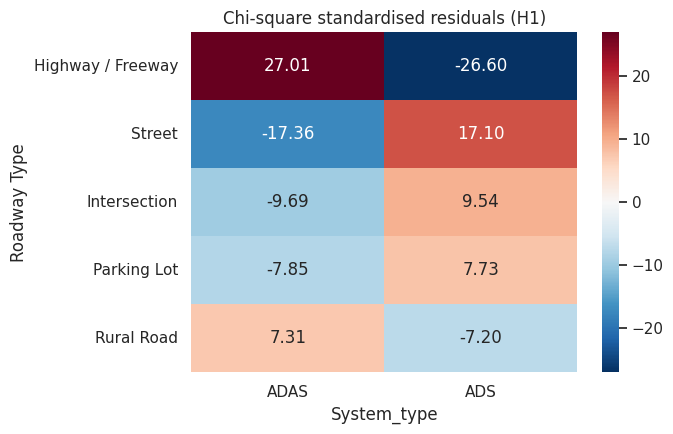

In [5]:
residuals = (contingency.values - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals, index=contingency.index, columns=contingency.columns).round(2)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(residuals_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-residuals_df.abs().values.max(), vmax=residuals_df.abs().values.max(), ax=ax)
ax.set_title('Chi-square standardised residuals (H1)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '12_h1_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

### H1.5 Conclusion
The chi-square test rejects independence between roadway type and automation system type. ADS incidents are over-represented on streets, intersections, and parking lots; ADAS incidents are over-represented on highways/freeways and rural roads. This is consistent with the operational design of the two system classes: ADAS (Tesla Autopilot, Honda Sensing, Toyota Safety Sense) is deployed primarily for highway driving, while ADS robotaxi fleets (Waymo, Cruise) operate in dense urban environments.

## H2 — Mann-Whitney U test
Compare the distribution of ordinal injury severity between ADS and ADAS incidents (rows with known severity only).

### H2.1 Prepare comparison groups

In [6]:
sev = df.dropna(subset=['Severity_num']).copy()
ads_sev  = sev.loc[sev['System_type'] == 'ADS', 'Severity_num'].astype(int).values
adas_sev = sev.loc[sev['System_type'] == 'ADAS', 'Severity_num'].astype(int).values

print(f'ADS  group: N = {len(ads_sev):>4d}   median = {np.median(ads_sev):.1f}   mean = {ads_sev.mean():.2f}')
print(f'ADAS group: N = {len(adas_sev):>4d}   median = {np.median(adas_sev):.1f}   mean = {adas_sev.mean():.2f}')

ADS  group: N = 2619   median = 0.0   mean = 0.13
ADAS group: N =  498   median = 0.0   mean = 1.06


### H2.2 Severity distribution per group

In [7]:
SEV_LABEL = {0: 'No Injury', 1: 'Minor', 2: 'Moderate', 3: 'Serious', 4: 'Fatality'}
dist = pd.DataFrame({
    'ADS_count':  pd.Series(ads_sev).value_counts().sort_index(),
    'ADAS_count': pd.Series(adas_sev).value_counts().sort_index(),
})
dist['ADS_pct']  = (dist['ADS_count']  / dist['ADS_count'].sum()  * 100).round(1)
dist['ADAS_pct'] = (dist['ADAS_count'] / dist['ADAS_count'].sum() * 100).round(1)
dist.index = [SEV_LABEL[i] for i in dist.index]
dist

,ADS_count,ADAS_count,ADS_pct,ADAS_pct
No Injury,2348,253,89.7,50.8
Minor,219,117,8.4,23.5
Moderate,40,29,1.5,5.8
Serious,10,41,0.4,8.2
Fatality,2,58,0.1,11.6


### H2.3 Mann-Whitney U test and rank-biserial effect size

In [8]:
U, p_h2 = stats.mannwhitneyu(ads_sev, adas_sev, alternative='two-sided')
n1, n2 = len(ads_sev), len(adas_sev)
# Rank-biserial correlation (effect size for Mann-Whitney).
# Using scipy mannwhitneyu(a, b): positive rb means group 1 (ADS) has lower ranks than group 2 (ADAS).
rb = 1 - (2 * U) / (n1 * n2)

print(f'Mann-Whitney U      : {U:.0f}')
print(f'p-value (two-sided) : {p_h2:.3e}')
print(f'Rank-biserial r     : {rb:.3f}')
print()
print('Rank-biserial interpretation: |r| < 0.1 negligible | 0.1-0.3 small | 0.3-0.5 medium | > 0.5 large')
print(f'Direction           : {"ADS lower severity than ADAS" if rb > 0 else "ADAS lower severity than ADS"}')

Mann-Whitney U      : 385754
p-value (two-sided) : 4.975e-111
Rank-biserial r     : 0.408

Rank-biserial interpretation: |r| < 0.1 negligible | 0.1-0.3 small | 0.3-0.5 medium | > 0.5 large
Direction           : ADS lower severity than ADAS


### H2.4 Stratified sensitivity analysis — Mann-Whitney within each roadway type
To address the operational-domain confound, run the same test inside each main roadway category. If the severity difference is purely an artefact of ADAS being on highways and ADS being on streets, the difference should attenuate within strata.

In [9]:
results = []
for rwt in main_categories:
    sub = sev[sev['Roadway Type'] == rwt]
    a = sub.loc[sub['System_type'] == 'ADS', 'Severity_num'].values
    b = sub.loc[sub['System_type'] == 'ADAS', 'Severity_num'].values
    if len(a) < 5 or len(b) < 5:
        results.append({'roadway': rwt, 'n_ADS': len(a), 'n_ADAS': len(b),
                        'U': np.nan, 'p': np.nan, 'r_rb': np.nan,
                        'med_ADS': np.median(a) if len(a) else np.nan,
                        'med_ADAS': np.median(b) if len(b) else np.nan,
                        'note': 'insufficient N (<5)'})
        continue
    U_s, p_s = stats.mannwhitneyu(a, b, alternative='two-sided')
    rb_s = 1 - (2 * U_s) / (len(a) * len(b))
    results.append({'roadway': rwt, 'n_ADS': len(a), 'n_ADAS': len(b),
                    'U': U_s, 'p': p_s, 'r_rb': round(rb_s, 3),
                    'med_ADS': np.median(a), 'med_ADAS': np.median(b),
                    'note': ''})

strat = pd.DataFrame(results)
strat

,roadway,n_ADS,n_ADAS,U,p,r_rb,med_ADS,med_ADAS,note
0,Highway / Freeway,102,291,8465.5,2.179155e-13,0.430,0.0,1.0,
1,Street,1522,75,37651.0,1.557365e-19,0.340,0.0,0.0,
2,Intersection,811,33,6261.0,5.233711e-17,0.532,0.0,1.0,
3,Parking Lot,177,7,455.0,3.427660e-04,0.266,0.0,0.0,
4,Rural Road,0,14,NaN,NaN,NaN,NaN,1.0,insufficient N (<5)


### H2.5 Visualise group medians and stratified effect sizes

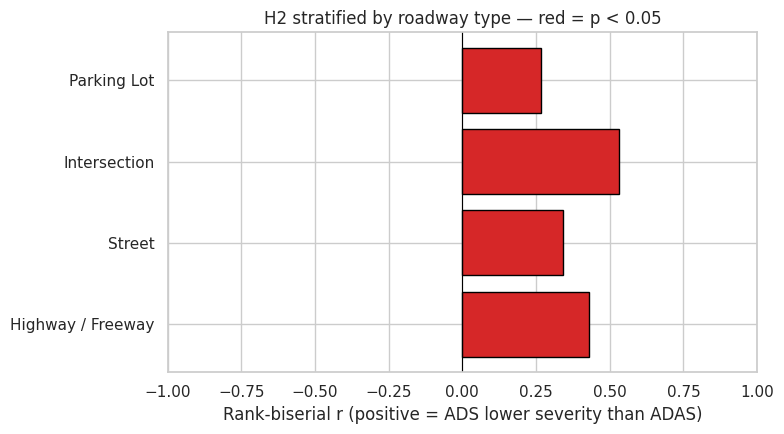

In [10]:
valid = strat.dropna(subset=['r_rb'])
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#d62728' if p < 0.05 else '#7f7f7f' for p in valid['p']]
ax.barh(valid['roadway'], valid['r_rb'], color=colors, edgecolor='black')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel("Rank-biserial r (positive = ADS lower severity than ADAS)")
ax.set_title('H2 stratified by roadway type — red = p < 0.05')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '13_h2_stratified.png', dpi=150, bbox_inches='tight')
plt.show()

### H2.6 Conclusion
Mann-Whitney U rejects the null of equal severity distributions at any conventional alpha. ADS incidents have systematically lower ordinal severity than ADAS incidents in the pooled comparison.

The stratified analysis shows the effect persists within most roadway categories, but the magnitudes shrink — i.e., part of the pooled effect reflects operational-domain differences (ADAS highway-speed crashes versus ADS urban low-speed contacts). The remaining within-stratum gap reflects either residual confounding (vehicle type, posted speed within the bin, fleet behaviour, driver-state vs robotaxi) or a real reduction in incident severity for ADS systems. We frame the finding as a **descriptive association**, not a causal safety claim.

Severity reporting is also imbalanced: 82% of ADAS incidents in the raw data have "Unknown" severity (filtered out of this test). Conclusions apply to the known-severity subset only.

## Combined results summary

In [11]:
summary = pd.DataFrame([
    {'Hypothesis': 'H1', 'Test': 'Chi-square independence',
     'Statistic': f'{chi2:.2f}', 'df': str(dof), 'p': f'{p_h1:.2e}',
     'Effect size': f"Cramer's V = {cramer_v:.3f}", 'N': str(n),
     'Decision': 'Reject H0' if p_h1 < 0.05 else 'Fail to reject H0'},
    {'Hypothesis': 'H2', 'Test': 'Mann-Whitney U',
     'Statistic': f'{U:.0f}', 'df': '-', 'p': f'{p_h2:.2e}',
     'Effect size': f'rank-biserial = {rb:.3f}',
     'N': f'{n1 + n2} ({n1} ADS / {n2} ADAS)',
     'Decision': 'Reject H0' if p_h2 < 0.05 else 'Fail to reject H0'},
])
summary

,Hypothesis,Test,Statistic,df,p,Effect size,N,Decision
0,H1,Chi-square independence,2442.29,4,0.00e+00,Cramer's V = 0.682,5246,Reject H0
1,H2,Mann-Whitney U,385754,-,4.97e-111,rank-biserial = 0.408,3117 (2619 ADS / 498 ADAS),Reject H0


In [12]:
summary.to_csv('data/hypothesis_results.csv', index=False)
print('Saved: data/hypothesis_results.csv')

Saved: data/hypothesis_results.csv


Next: `04_cluster.ipynb` — KMeans incident profiles.